# Lab-4: Applied Statistical Modeling & Interactive Web Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

In [3]:
insurance_df = pd.read_csv("insurance.csv")
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
insurance_df.shape

(1338, 7)

In [5]:
insurance_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [6]:
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [7]:
insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

descriptive_stats = pd.DataFrame({
    'Mean': insurance_df[numerical_cols].mean(),
    'Median': insurance_df[numerical_cols].median(),
    'Standard Deviation': insurance_df[numerical_cols].std(),
    'IQR': insurance_df[numerical_cols].quantile(0.75) - insurance_df[numerical_cols].quantile(0.25),
    'Skewness': insurance_df[numerical_cols].skew(),
    'Kurtosis': insurance_df[numerical_cols].kurtosis()
})

descriptive_stats

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
age,39.207025,39.000,14.049960,24.000000,0.055673,-1.245088
bmi,30.663397,30.400,6.098187,8.397500,0.284047,-0.050732
children,1.094918,1.000,1.205493,2.000000,0.938380,0.202454
charges,13270.422265,9382.033,12110.011237,11899.625365,1.515880,1.606299


In [10]:
import os

os.makedirs("plots/01_eda/distribution_plots", exist_ok=True)
os.makedirs("plots/01_eda/scatter_plots", exist_ok=True)
os.makedirs("plots/01_eda/correlation_matrix", exist_ok=True)
os.makedirs("plots/02_hypothesis_testing/hypothesis_plots", exist_ok=True)
os.makedirs("plots/03_regression/residuals_vs_fitted", exist_ok=True)
os.makedirs("plots/03_regression/regression_plots", exist_ok=True)
os.makedirs("plots/04_diagnostics/qq_plot", exist_ok=True)
os.makedirs("plots/04_diagnostics/other_diagnostics", exist_ok=True)

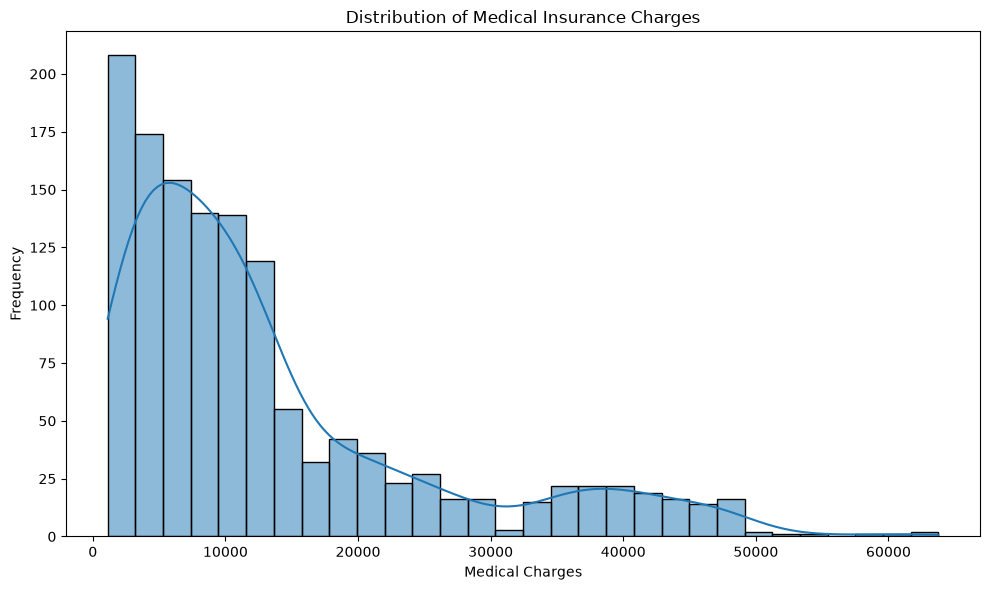

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    insurance_df['charges'],
    kde=True
)

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Medical Charges')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/distribution_plots/medical_charges_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**

### The distribution of medical insurance charges is positively/right-skewed, with most observations having relatively lower charges and a smaller number of observations having very high charges. This agrees with the calculated skewness of 1.516. The presence of high-charge observations also explains why the mean (13,270.42) is considerably higher than the median (9,382.03).

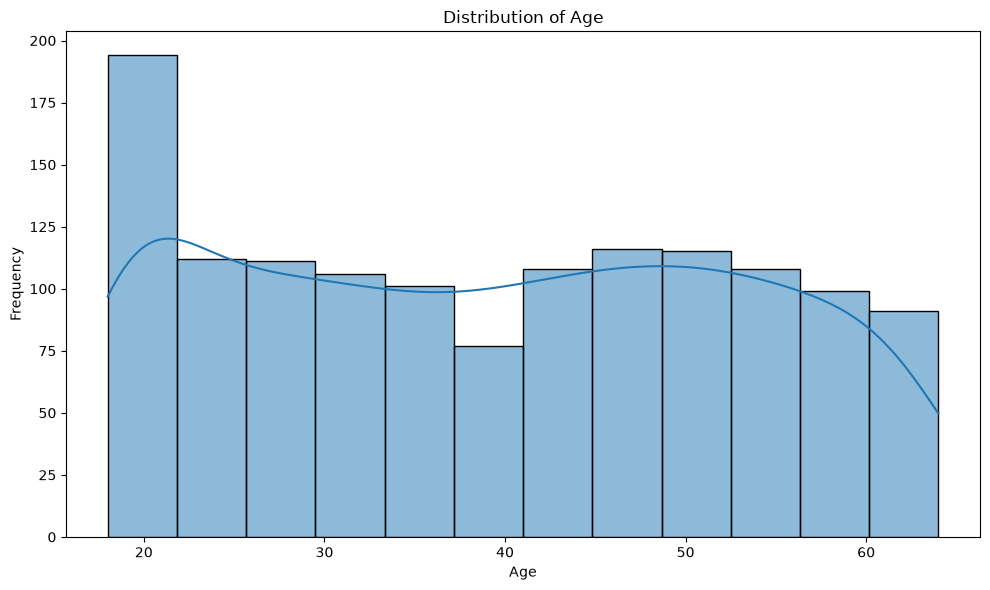

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    insurance_df['age'],
    kde=True
)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/distribution_plots/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The histogram shows that the age distribution ranges from approximately 18 to 64 years. The highest frequency is observed among people aged around 18–22 years, with nearly 195 individuals. The remaining age groups have relatively similar frequencies, mostly ranging between 90 and 115 individuals. There is also a noticeable concentration of individuals around 45–52 years. Overall, the distribution is fairly balanced, with slightly higher representation among younger adults and middle-aged individuals.

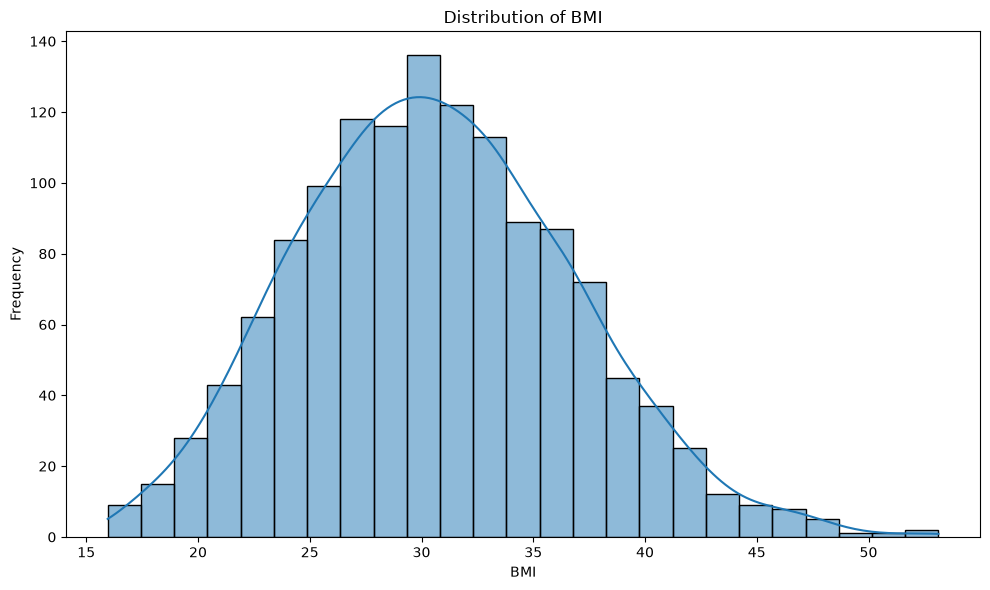

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    insurance_df['bmi'],
    kde=True
)

plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/distribution_plots/bmi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The histogram shows that the BMI values range from approximately 16 to 53. The distribution is unimodal, with the highest frequency occurring around a BMI of 28–32, peaking near 30. Most individuals have BMI values between 25 and 38. The frequency gradually decreases for BMI values above 38, creating a right-skewed distribution with a small number of individuals having very high BMI values. Overall, most of the data is concentrated around the normal to overweight BMI range, with fewer observations at the extreme values.

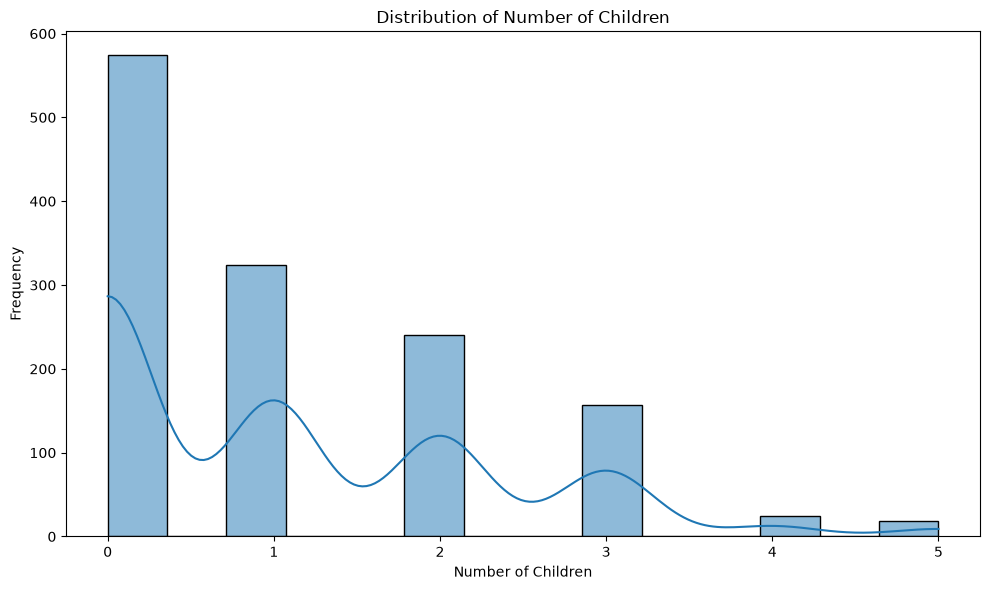

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    insurance_df['children'],
    kde=True
)

plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/distribution_plots/children_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The histogram shows that the number of children ranges from 0 to 5. The highest frequency is observed for individuals with 0 children, followed by those with 1 child. The frequency gradually decreases as the number of children increases, with relatively few individuals having 4 or 5 children. Overall, the distribution is right-skewed, indicating that most individuals have few or no children, while only a small proportion have a larger number of children.

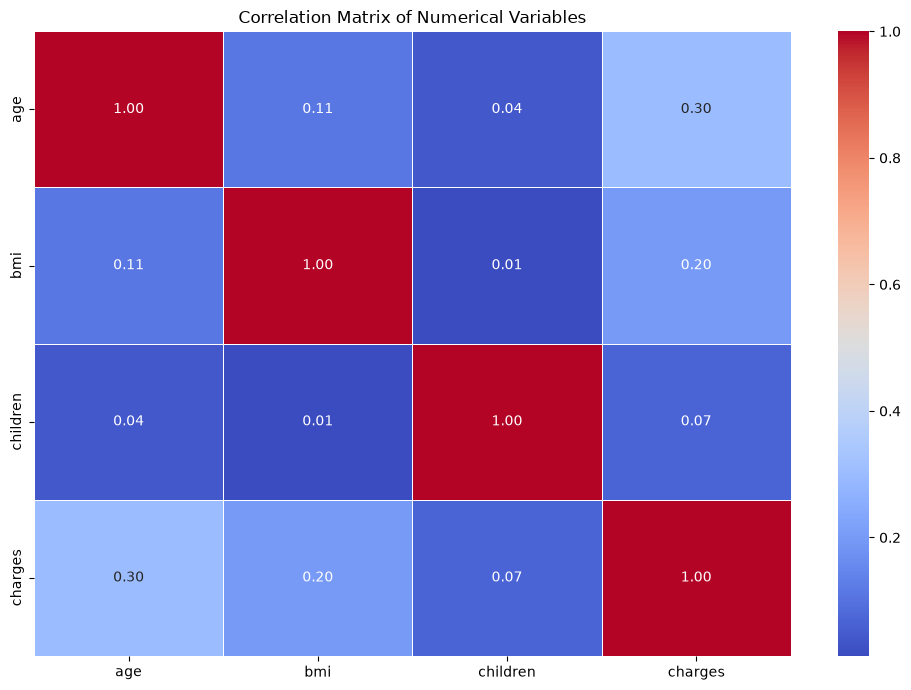

In [16]:
plt.figure(figsize=(10, 7))

correlation_matrix = insurance_df[
    ['age', 'bmi', 'children', 'charges']
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/correlation_matrix/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The correlation matrix shows that age and charges have the strongest positive correlation (0.30), meaning medical charges tend to increase slightly with age. BMI and charges also show a weak positive correlation (0.20). The correlation between children and charges is very weak (0.07), while age, BMI, and children are almost uncorrelated with each other.

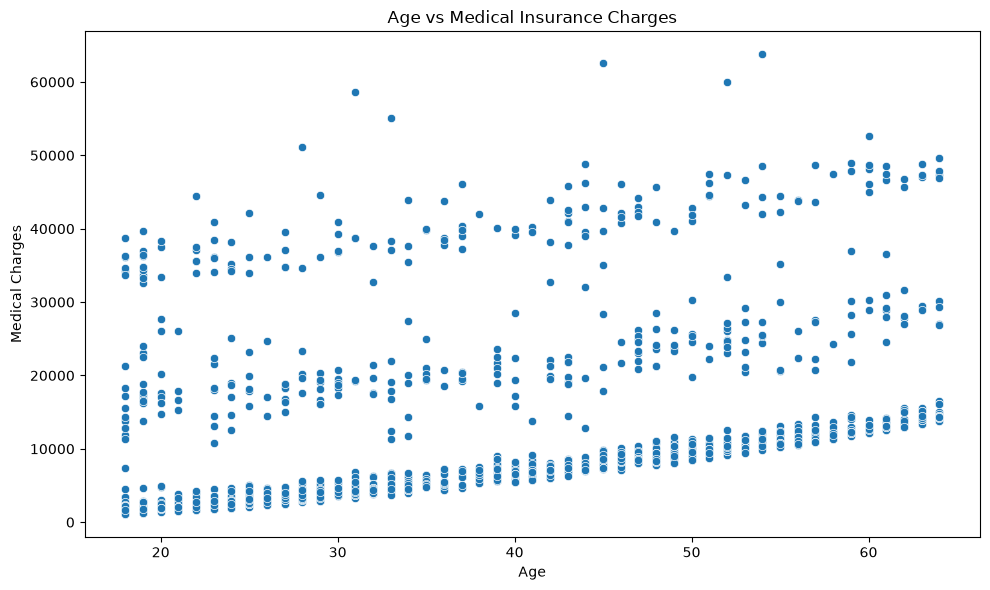

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=insurance_df,
    x='age',
    y='charges'
)

plt.title('Age vs Medical Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/scatter_plots/age_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The scatter plot shows a positive relationship between age and medical insurance charges. As age increases, medical expenses generally tend to increase, although there is considerable variation among individuals. Most lower charges gradually rise from around $2,000–$5,000 for younger people to $12,000–$16,000 for older people. There are also several groups with much higher charges, reaching $30,000–$60,000+, particularly among older individuals. Overall, the plot suggests that age is an important factor associated with higher medical insurance charges, but other factors also contribute significantly to the variation.

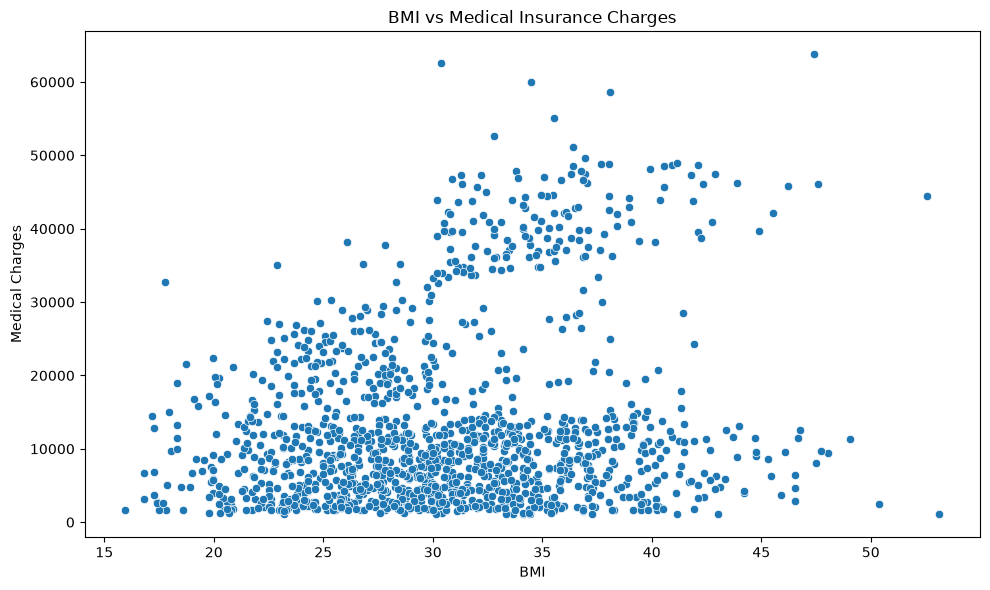

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=insurance_df,
    x='bmi',
    y='charges'
)

plt.title('BMI vs Medical Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/scatter_plots/bmi_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The scatter plot shows a positive relationship between BMI and medical insurance charges, although the relationship is not very strong across all observations. Most individuals have medical charges below $15,000, regardless of BMI. However, higher charges, particularly above $30,000, become more common as BMI increases, especially for BMI values around 30–45. The plot also contains several high-cost outliers reaching above $60,000. Overall, higher BMI tends to be associated with higher medical insurance charges, but BMI alone does not fully explain the variation in charges.

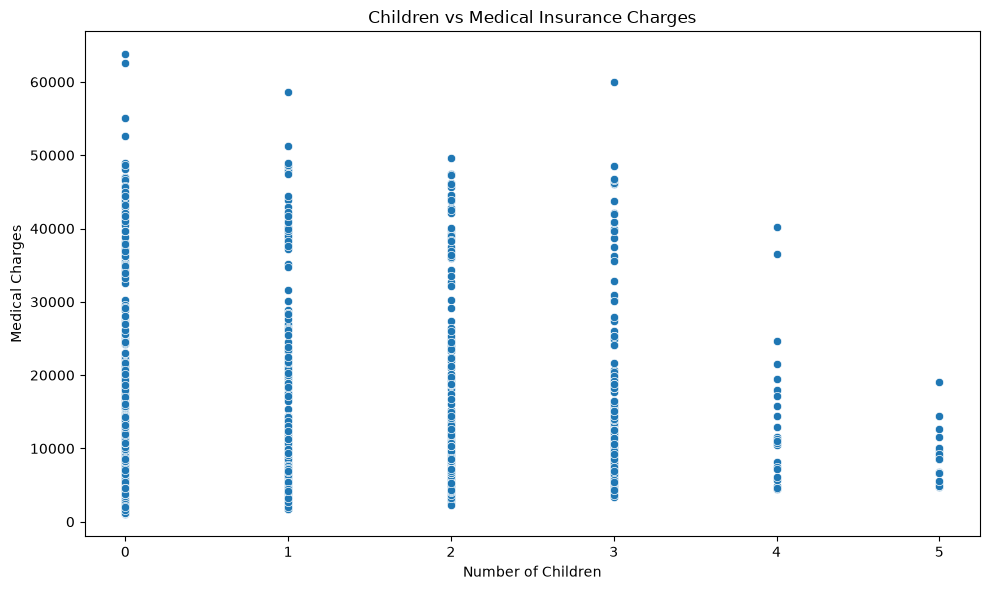

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=insurance_df,
    x='children',
    y='charges'
)

plt.title('Children vs Medical Insurance Charges')
plt.xlabel('Number of Children')
plt.ylabel('Medical Charges')
plt.tight_layout()

plt.savefig(
    "plots/01_eda/scatter_plots/children_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The scatter plot shows that the number of children has a relatively weak relationship with medical insurance charges. Most individuals across all child categories have charges below $15,000, while some individuals have much higher charges, reaching over $60,000. The highest charges are mainly observed among people with 0–3 children, whereas those with 4–5 children have fewer observations and generally lower charges. Overall, the number of children does not appear to have a strong direct effect on medical insurance charges, and other factors such as age, BMI, and smoking status are likely more influential.

# Hypothesis Testing – Test 1

In [20]:
smoker_charges = insurance_df[insurance_df['smoker'] == 'yes']['charges']
non_smoker_charges = insurance_df[insurance_df['smoker'] == 'no']['charges']

group_summary = insurance_df.groupby('smoker')['charges'].agg(
    ['count', 'mean', 'median', 'std']
)

group_summary

,count,mean,median,std
smoker,,,,
no,1064,8434.268298,7345.40530,5993.781819
yes,274,32050.231832,34456.34845,11541.547176


## *Observation:*
### There appears to be a large difference in medical charges between smokers and non-smokers. However, descriptive statistics alone cannot determine whether this difference is statistically significant. Therefore, we perform hypothesis testing.

In [21]:
from scipy import stats

shapiro_smoker = stats.shapiro(smoker_charges)

shapiro_non_smoker = stats.shapiro(non_smoker_charges)

print("Shapiro-Wilk Test - Smokers")
print(f"Statistic: {shapiro_smoker.statistic:.4f}")
print(f"P-value: {shapiro_smoker.pvalue:.6f}")

print()

print("Shapiro-Wilk Test - Non-Smokers")
print(f"Statistic: {shapiro_non_smoker.statistic:.4f}")
print(f"P-value: {shapiro_non_smoker.pvalue:.6f}")

Shapiro-Wilk Test - Smokers
Statistic: 0.9396
P-value: 0.000000

Shapiro-Wilk Test - Non-Smokers
Statistic: 0.8729
P-value: 0.000000


## **Observation:**
### The Shapiro-Wilk test checks whether a dataset is approximately normally distributed.
### Decision Rule:
#### p-value > 0.05 → Fail to Reject H₀ → data can be considered approximately normal.
#### p-value ≤ 0.05 → Reject H₀ → data is not normally distributed.
### The medical charges for both smokers and non-smokers do not follow a normal distribution.
### This means the normality assumption required for the standard independent two-sample t-test is not satisfied. Therefore, according to the assignment, we should use the Mann-Whitney U test, a non-parametric alternative

In [22]:
levene_test = stats.levene(
    smoker_charges,
    non_smoker_charges
)

print("Levene's Test for Equal Variances")
print(f"Statistic: {levene_test.statistic:.4f}")
print(f"P-value: {levene_test.pvalue:.6f}")

Levene's Test for Equal Variances
Statistic: 332.6135
P-value: 0.000000


## **Observation:**
### There is a statistically significant difference in the variances of medical charges between smokers and non-smokers.

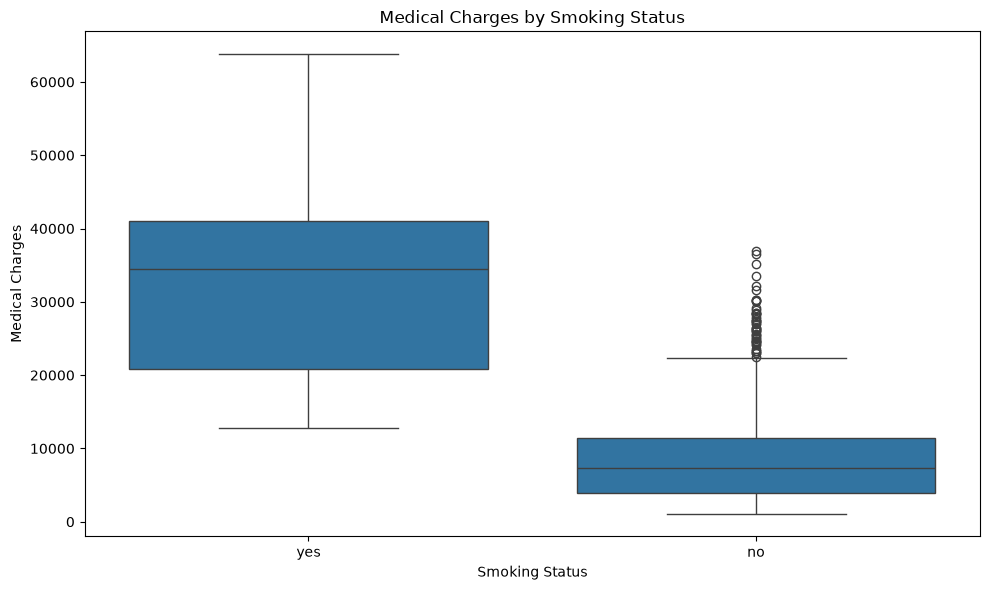

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=insurance_df,
    x='smoker',
    y='charges'
)

plt.title('Medical Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Medical Charges')

plt.tight_layout()

plt.savefig(
    "plots/02_hypothesis_testing/hypothesis_plots/charges_by_smoker.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The boxplot shows a clear difference in the distribution of medical charges between smokers and non-smokers. Smokers generally have substantially higher medical charges than non-smokers.

In [24]:
mann_whitney_test = stats.mannwhitneyu(
    smoker_charges,
    non_smoker_charges,
    alternative='two-sided'
)

print("Mann-Whitney U Test")
print(f"U Statistic: {mann_whitney_test.statistic:.4f}")
print(f"P-value: {mann_whitney_test.pvalue:.6f}")

Mann-Whitney U Test
U Statistic: 284133.0000
P-value: 0.000000


## Final Conclusion

### The Shapiro-Wilk test showed that medical charges were not normally distributed for both smokers and non-smokers (p < 0.05). Levene's test also indicated that the variances of the two groups were significantly different (p < 0.05).

### Therefore, the non-parametric Mann-Whitney U test was selected.

### The Mann-Whitney U test produced a U statistic of 284133.0000 and a p-value of less than 0.05. Hence, the null hypothesis (H₀) is rejected.

### There is a statistically significant difference in the distribution of medical insurance charges between smokers and non-smokers.

### The descriptive statistics and boxplot also show that smokers generally have substantially higher medical charges than non-smokers.

# # Hypothesis Testing – Test 2

In [26]:
region_summary = insurance_df.groupby('region')['charges'].agg(
    ['count', 'mean', 'median', 'std']
)
region_summary

,count,mean,median,std
region,,,,
northeast,324,13406.384516,10057.652025,11255.803066
northwest,325,12417.575374,8965.795750,11072.276928
southeast,364,14735.411438,9294.131950,13971.098589
southwest,325,12346.937377,8798.593000,11557.179101


## **Observation:**
### There are some differences in average medical charges between regions, with the Southeast having the highest mean and the Southwest having the lowest. However, these differences need to be tested statistically to determine whether they are significant.

In [27]:
northeast = insurance_df[insurance_df['region'] == 'northeast']['charges']
northwest = insurance_df[insurance_df['region'] == 'northwest']['charges']
southeast = insurance_df[insurance_df['region'] == 'southeast']['charges']
southwest = insurance_df[insurance_df['region'] == 'southwest']['charges']

anova_result = stats.f_oneway(
    northeast,
    northwest,
    southeast,
    southwest
)

print("One-Way ANOVA Test")
print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"P-value: {anova_result.pvalue:.6f}")

One-Way ANOVA Test
F-statistic: 2.9696
P-value: 0.030893


## **Observation:**
### There is a statistically significant difference in mean medical insurance charges among the four regions.
## ANOVA Interpretation:
### The One-Way ANOVA produced an F-statistic of 2.9696 and a p-value of 0.030893.
### Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.
### Therefore, there is a statistically significant difference in mean medical insurance charges among the four regions.
### However, ANOVA only indicates that at least one regional mean is different. It does not identify which specific regions differ.

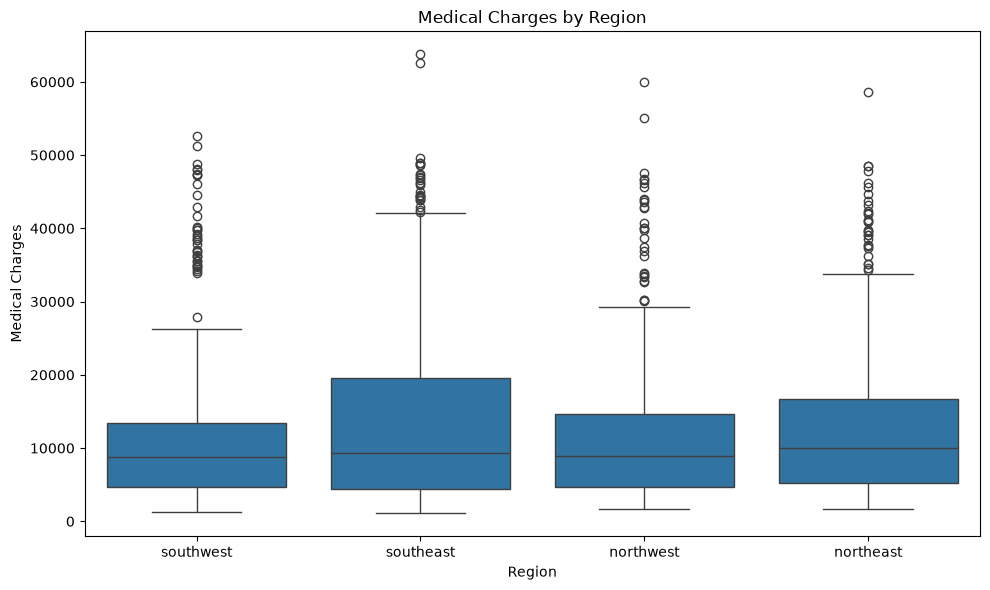

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=insurance_df, x='region', y='charges')

plt.title('Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Medical Charges')

plt.tight_layout()

plt.savefig(
    "plots/02_hypothesis_testing/hypothesis_plots/charges_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### Medical charges vary across regions, with the Southeast showing the highest average charges and the Southwest showing the lowest. The One-Way ANOVA indicates that there is a statistically significant difference in mean medical charges among the four regions (F = 2.9696, p = 0.030893). However, the boxplot shows substantial overlap and many outliers across all regions. ANOVA only indicates that at least one region differs from another; it does not identify the specific pairs of regions that differ.

## **Final Conclusion:**
### H₀: The mean medical charges are equal across all four regions.
### H₁: At least one regional mean is different.
### α = 0.05
### F-statistic = 2.9696
### p-value = 0.030893
### Since p-value < 0.05:
### Reject H₀.
### There is a statistically significant difference in medical charges among the four regions.

In [29]:
import statsmodels.api as sm

regression_df = insurance_df.copy()

regression_df = pd.get_dummies(
    regression_df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

regression_df = regression_df.astype(float)

X = regression_df.drop('charges', axis=1)
y = regression_df['charges']

X = sm.add_constant(X)

print("Independent variables:")
print(X.columns.tolist())

Independent variables:
['const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [30]:
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:31:19   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

## **Observation:**
### The regression model provides a good explanation of medical insurance charges, with approximately 75.1% of the variation explained by the selected variables. Smoking status is the strongest predictor in the model, followed by age and BMI. Most major predictors are statistically significant, while sex and the Northwest region do not show significant effects after controlling for the other variables.

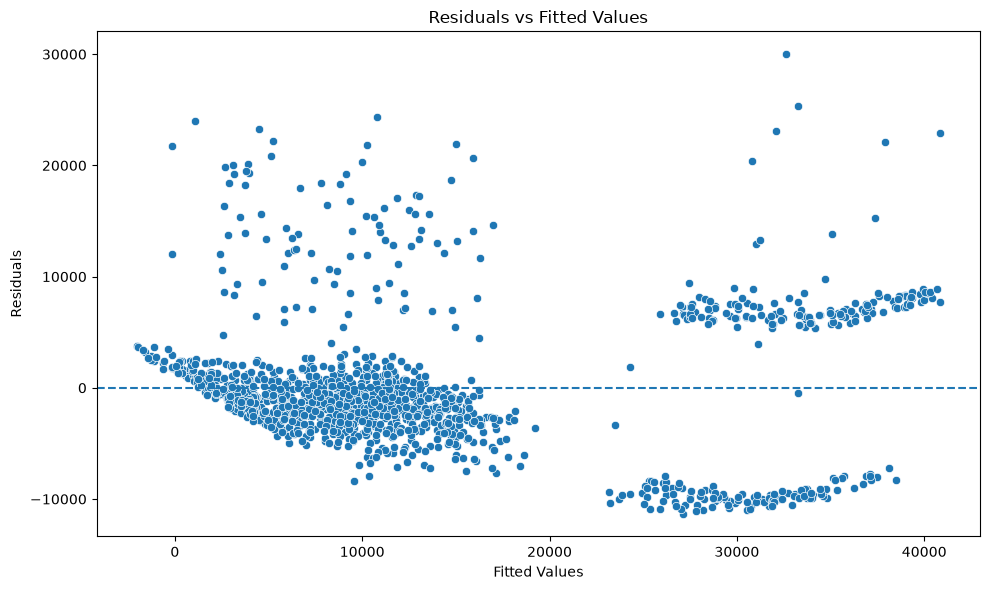

In [31]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(10, 6))

sns.scatterplot(x=fitted_values, y=residuals)

plt.axhline(y=0, linestyle='--')

plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.tight_layout()

plt.savefig(
    "plots/03_regression/residuals_vs_fitted/residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**
### The residuals are centered around zero but do not have a completely constant spread. The presence of large residuals and visible clustering suggests possible heteroscedasticity and indicates that some variation in medical charges is not fully captured by the linear regression model.

<Figure size 1000x600 with 0 Axes>

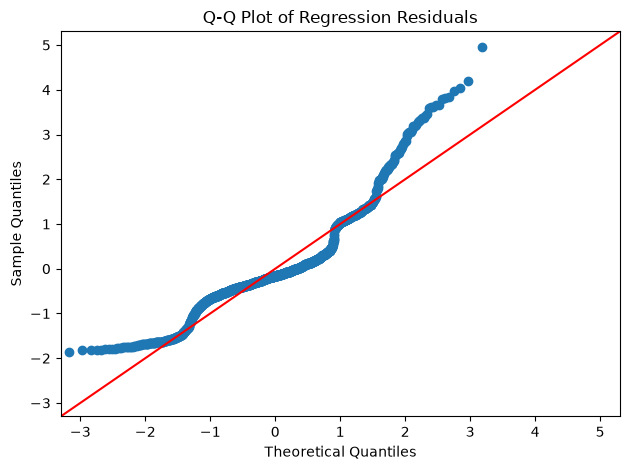

In [32]:
import statsmodels.api as sm

plt.figure(figsize=(10, 6))

sm.qqplot(residuals, line='45', fit=True)

plt.title('Q-Q Plot of Regression Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.tight_layout()

plt.savefig(
    "plots/04_diagnostics/qq_plot/residuals_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observation:**

### The Q-Q plot shows substantial deviation from the reference line, indicating that the regression residuals are not normally distributed. The residuals exhibit positive skewness and heavy tails, which is consistent with the Omnibus and Jarque-Bera test results.

In [34]:
from statsmodels.stats.stattools import omni_normtest, jarque_bera, durbin_watson

print("Residual Diagnostics")
print("-" * 40)

omnibus_stat, omnibus_p = omni_normtest(residuals)

jb_stat, jb_p, skewness, kurtosis = jarque_bera(residuals)

dw_stat = durbin_watson(residuals)

print(f"Omnibus Statistic: {omnibus_stat:.4f}")
print(f"Omnibus P-value: {omnibus_p:.6e}")

print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"Jarque-Bera P-value: {jb_p:.6e}")

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

print(f"Durbin-Watson: {dw_stat:.4f}")

Residual Diagnostics
----------------------------------------
Omnibus Statistic: 300.3659
Omnibus P-value: 5.975444e-66
Jarque-Bera Statistic: 718.8873
Jarque-Bera P-value: 7.863469e-157
Skewness: 1.2112
Kurtosis: 5.6508
Durbin-Watson: 2.0884


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.drop('const', axis=1)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Variable,VIF
0,age,1.016822
1,bmi,1.106630
2,children,1.004011
3,sex_male,1.008900
4,smoker_yes,1.012074
5,region_northwest,1.518823
6,region_southeast,1.652230
7,region_southwest,1.529411


## **Observation:**
### The VIF results indicate very low multicollinearity in the regression model. All predictor variables have VIF values close to 1, suggesting that the independent variables provide relatively distinct information. Therefore, multicollinearity is not a major concern for this model.

## **Overall Regression Diagnostics:**

### The regression diagnostics show that the model does not have a serious multicollinearity problem because all VIF values are below 2.

### The Durbin-Watson statistic of approximately 2.088 suggests that there is no strong evidence of residual autocorrelation.

### However, the Residuals vs Fitted plot indicates possible heteroscedasticity because the residual spread is not constant across fitted values. The Q-Q plot, along with the Omnibus and Jarque-Bera tests, indicates that the residuals are not normally distributed.

### Therefore, while the OLS model provides a good overall fit and has no major multicollinearity issue, some regression assumptions are not fully satisfied.

In [36]:
import os
import joblib

os.makedirs("models", exist_ok=True)

model_data = {
    "model": ols_model,
    "features": X.columns.tolist()
}

joblib.dump(model_data, "models/ols_model.pkl")

print("OLS model saved successfully!")
print("Model path: models/ols_model.pkl")
print("Features:", model_data["features"])

OLS model saved successfully!
Model path: models/ols_model.pkl
Features: ['const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [37]:
loaded_model_data = joblib.load("models/ols_model.pkl")

loaded_model = loaded_model_data["model"]
loaded_features = loaded_model_data["features"]

print("Model loaded successfully!")
print("Number of features:", len(loaded_features))

Model loaded successfully!
Number of features: 9


In [38]:
sample_input = pd.DataFrame({
    'const': [1],
    'age': [35],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

prediction_result = loaded_model.get_prediction(sample_input)

prediction_summary = prediction_result.summary_frame(alpha=0.05)

prediction_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6503.111872,423.934466,5671.458184,7334.76556,-5418.264963,18424.488707
